<a href="https://colab.research.google.com/github/eddieZayed/Ackerra-FitnessPlatform/blob/main/Housing_Segmentation_and_Price_Prediction_using_Machine_Learning_%26_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1 Imports

In [ ]:
from google.colab import drive
from sklearn import set_config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import metrics
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

!pip install keras-tuner
import keras_tuner as kt
from keras_tuner import HyperParameters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.3 MB/s eta 0:00:00


#2 Data loading

In [ ]:
drive.mount('/content/drive')
fpath = "/content/drive/My Drive/Colab Notebooks/Third Belt Exam/option_A_clustering_df - option_A_clustering_df.csv"
df = pd.read_csv(fpath)
pd.set_option('display.max_columns', None)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,SalePrice,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,Longitude,Latitude
0,400000,1590,0,0,0,3180,1590,1590,0,600,1,50,0,220,0,6,0,2,1,1965,-122.196399,47.336118
1,474250,1390,0,0,0,2200,810,810,0,0,1,0,0,340,0,4,1,0,1,1945,-122.361913,47.509874
2,667950,1010,0,1515,0,2525,0,0,0,400,0,167,0,0,0,4,1,0,2,2019,-122.156684,47.437557
3,659000,660,0,540,0,1820,620,620,0,0,1,0,0,100,0,3,1,0,2,2016,-122.370252,47.565146
4,656500,2310,0,0,0,2310,0,0,0,440,0,40,0,320,0,3,0,0,2,1967,-122.184194,47.730389


#3 Data Cleaning

In [ ]:
set_config(transform_output = "pandas")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4944 entries, 0 to 4943
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SalePrice           4944 non-null   int64  
 1   SqFt1stFloor        4944 non-null   int64  
 2   SqFtHalfFloor       4944 non-null   int64  
 3   SqFt2ndFloor        4944 non-null   int64  
 4   SqFtUpperFloor      4944 non-null   int64  
 5   SqFtTotLiving       4944 non-null   int64  
 6   SqFtTotBasement     4944 non-null   int64  
 7   SqFtFinBasement     4944 non-null   int64  
 8   SqFtGarageBasement  4944 non-null   int64  
 9   SqFtGarageAttached  4944 non-null   int64  
 10  DaylightBasement    4944 non-null   int64  
 11  SqFtOpenPorch       4944 non-null   int64  
 12  SqFtEnclosedPorch   4944 non-null   int64  
 13  SqFtDeck            4944 non-null   int64  
 14  BrickStone          4944 non-null   int64  
 15  Bedrooms            4944 non-null   int64  
 16  BathHa

##3.1 Handle duplicates

In [ ]:
print(f'Number of duplicated rows:{df.duplicated().sum()}')

Number of duplicated rows:29


In [ ]:
df = df.drop_duplicates() #removing duplicated rows
print(f'Number of duplicated rows:{df.duplicated().sum()}') #ensure duplicates are removed

Number of duplicated rows:0


##3.2 Handle incorrect dataTypes

In [ ]:
df.dtypes #Ensure all columns match the data types listed in the data dictionary.

,0
SalePrice,int64
SqFt1stFloor,int64
SqFtHalfFloor,int64
SqFt2ndFloor,int64
SqFtUpperFloor,int64
SqFtTotLiving,int64
SqFtTotBasement,int64
SqFtFinBasement,int64
SqFtGarageBasement,int64
SqFtGarageAttached,int64


All columns in the dataset are numeric (int64 or float64)

##3.3 Handle impossible numeric values

In [ ]:
df.describe().round(2)

,SalePrice,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,Longitude,Latitude
count,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.0,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00,4915.00
mean,664544.37,1179.08,51.96,347.44,26.52,1937.45,596.63,334.98,102.33,170.88,0.37,55.4,8.24,148.61,4.44,3.38,0.39,0.63,1.32,1971.92,-122.27,47.57
std,298577.38,444.93,174.81,544.87,114.67,765.66,567.98,423.70,187.33,239.93,0.48,96.0,37.50,201.62,18.70,0.95,0.51,0.65,0.61,32.82,0.09,0.13
min,60000.00,260.00,0.00,0.00,0.00,300.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1900.00,-122.53,47.21
25%,450000.00,880.00,0.00,0.00,0.00,1390.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,3.00,0.00,0.00,1.00,1952.00,-122.35,47.49
50%,630000.00,1170.00,0.00,0.00,0.00,1770.00,560.00,110.00,0.00,0.00,0.00,0.0,0.00,50.00,0.00,3.00,0.00,1.00,1.00,1966.00,-122.29,47.58
75%,789950.00,1450.00,0.00,580.00,0.00,2370.00,1070.00,570.00,190.00,400.00,1.00,80.0,0.00,250.00,0.00,4.00,1.00,1.00,2.00,2015.00,-122.19,47.68
max,1998000.00,3600.00,2000.00,3010.00,1220.00,6695.00,3070.00,2620.00,1090.00,1830.00,1.00,1060.0,620.00,1940.00,100.00,8.00,3.00,4.00,5.00,2019.00,-122.09,47.78


no impossible numeric values were identified in the dataset.

##3.4 Check for missing values

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
SalePrice,0
SqFt1stFloor,0
SqFtHalfFloor,0
SqFt2ndFloor,0
SqFtUpperFloor,0
SqFtTotLiving,0
SqFtTotBasement,0
SqFtFinBasement,0
SqFtGarageBasement,0
SqFtGarageAttached,0


No missing values

#4 Explore the data

##4.1 Correlation Heatmap

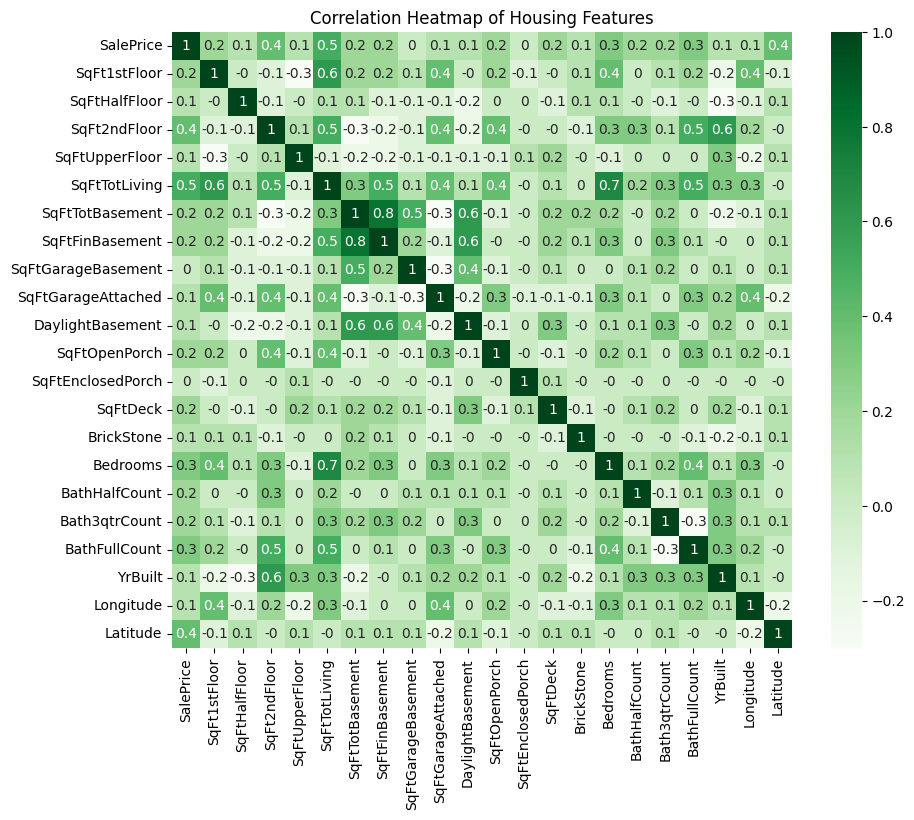

In [ ]:
corr = df.corr(numeric_only=True).round(1)

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(corr, cmap='Greens', annot=True, ax=ax)

ax.set_title('Correlation Heatmap of Housing Features')

plt.show()

- total living area have strong positive relationship with SalePrice, so bigger houses usually cost more

- Some basement features are also strongly related to each other because they measure similar parts of the house

- Other features like porches, decks, and brick/stone percentage have weaker relationships with price

##4.2 Total Living Area vs Sale Price

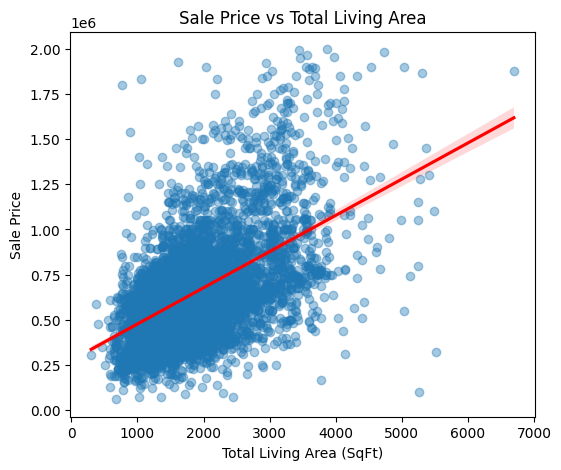

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

sns.regplot(data=df, x='SqFtTotLiving', y='SalePrice', ax=ax,
            scatter_kws={'alpha':0.4}, line_kws={'color':'red'})

ax.set_xlabel('Total Living Area (SqFt)')
ax.set_ylabel('Sale Price')
ax.set_title('Sale Price vs Total Living Area')

plt.show()

There is positive relationship between total living area and sale price. Houses with larger living areas generally tend to have higher sale prices.

##4.3 Distribution of Total Living Area

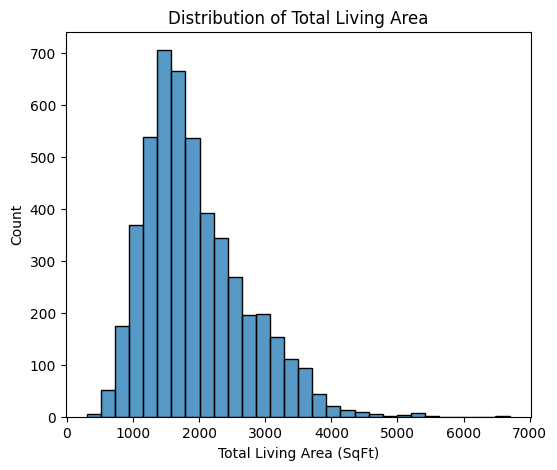

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

sns.histplot(data=df, x='SqFtTotLiving', bins=30, ax=ax)

ax.set_xlabel('Total Living Area (SqFt)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Total Living Area')

plt.show()

Most homes have a living area between about 1,000 and 3,000 square feet, with fewer very large houses. The distribution is slightly right-skewed, meaning there are a small number of houses with much larger living areas compared to the majority of homes.

#5 Clustering

In unsupervised learning -->The model should discover patterns in the houses based on their characteristics, not based on the price. so of SalePrice is included KMeans would mainly group houses by price, because price has large numeric values and strongly affects the distance calculation.then the clusters would become something like:cheap houses, medium price houses,expensive housesInstead of discovering true house types.



##5.1 Prepare the data for modeling

In [ ]:
# remove SalePrice before clustering because including it cause the clusters to be driven mainly by price instead of the physical features of the houses.
#so it is removed so the model can group homes based on their attributes such as size, structure..etc
X = df.drop(columns=['SalePrice'])

#scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#convert scaled data back to dataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,Longitude,Latitude
0,0.923656,-0.297264,-0.637725,-0.23133,1.623007,1.749140,2.962367,-0.546329,1.788670,1.296123,-0.056279,-0.21969,0.354131,-0.237616,2.770511,-0.766251,2.104538,-0.524838,-0.210761,0.869736,-1.854932
1,0.474097,-0.297264,-0.637725,-0.23133,0.342942,0.375708,1.121238,-0.546329,-0.712267,1.296123,-0.577180,-0.21969,0.949368,-0.237616,0.656060,1.209680,-0.961655,-0.524838,-0.820269,-1.043917,-0.490331
2,-0.380065,-0.297264,2.143060,-0.23133,0.767453,-1.050548,-0.790705,-0.546329,0.955024,-0.771532,1.162632,-0.21969,-0.737137,-0.237616,0.656060,1.209680,-0.961655,1.114030,1.434912,1.328909,-1.058280
3,-1.166792,-0.297264,0.353446,-0.23133,-0.153410,0.041154,0.672757,-0.546329,-0.712267,1.296123,-0.577180,-0.21969,-0.241106,-0.237616,-0.401165,1.209680,-0.961655,1.114030,1.343485,-1.140326,-0.056249
4,2.542067,-0.297264,-0.637725,-0.23133,0.486623,-1.050548,-0.790705,-0.546329,1.121753,-0.771532,-0.160459,-0.21969,0.850162,-0.237616,-0.401165,-0.766251,-0.961655,1.114030,-0.149810,1.010839,1.241497


##5.2 Find the Optimal Number of Clusters

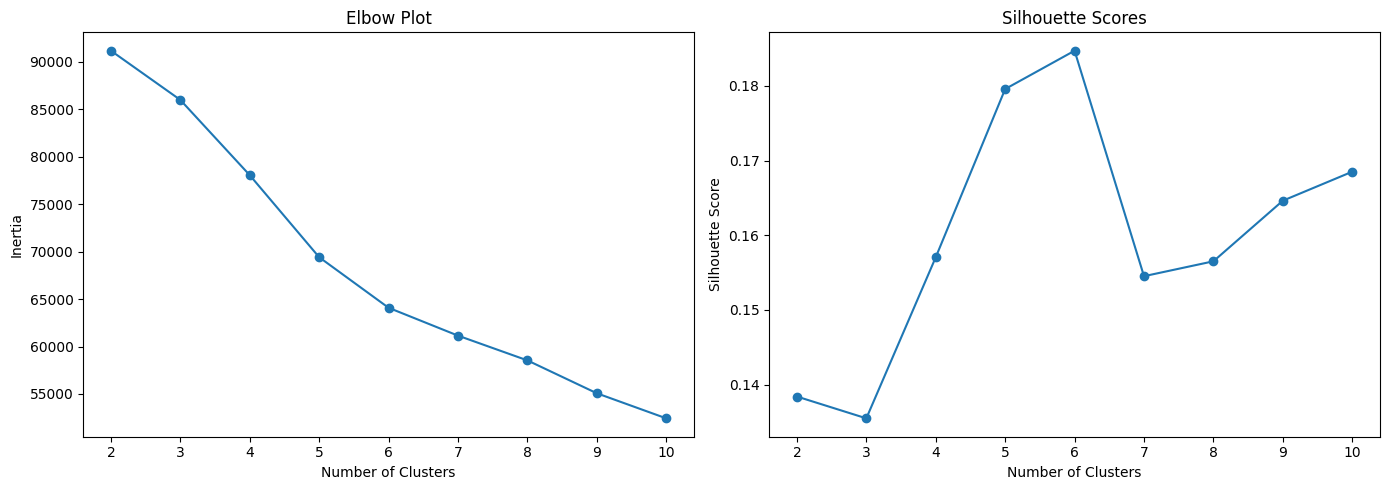

In [ ]:
ks = range(2, 11) #range of clusters to test

inertias = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


#plot inertia and silhouette score
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Elbow Plot')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(ks))

axes[1].plot(ks, silhouette_scores, marker='o')
axes[1].set_title('Silhouette Scores')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(ks))

plt.tight_layout()
plt.show()

- Based on the elbow plot, the decrease in inertia starts to slow down around 6 clusters In addition
- the silhouette score reaches its highest value at 6,
- therefore, 6 clusters were selected as the optimal number of clusters.

##5.3 Train the final KMeans model

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init='auto')

clusters = kmeans.fit_predict(X_scaled)

#add cluster labels to the original dataframe
df['Cluster'] = clusters

df.head()

,SalePrice,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,Longitude,Latitude,Cluster
0,400000,1590,0,0,0,3180,1590,1590,0,600,1,50,0,220,0,6,0,2,1,1965,-122.196399,47.336118,2
1,474250,1390,0,0,0,2200,810,810,0,0,1,0,0,340,0,4,1,0,1,1945,-122.361913,47.509874,2
2,667950,1010,0,1515,0,2525,0,0,0,400,0,167,0,0,0,4,1,0,2,2019,-122.156684,47.437557,4
3,659000,660,0,540,0,1820,620,620,0,0,1,0,0,100,0,3,1,0,2,2016,-122.370252,47.565146,5
4,656500,2310,0,0,0,2310,0,0,0,440,0,40,0,320,0,3,0,0,2,1967,-122.184194,47.730389,1


##5.4 Analyze and report on the clusters

In [ ]:
df.groupby('Cluster').mean()

,SalePrice,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,Longitude,Latitude
Cluster,,,,,,,,,,,,,,,,,,,,,,
0,761855.957020,1122.275072,606.681948,50.859599,0.000000,2017.581662,791.461318,246.074499,57.163324,62.676218,0.111748,59.220630,13.954155,95.478510,9.945559,3.756447,0.349570,0.375358,1.255014,1931.140401,-122.317647,47.616360
1,520384.727545,1227.772455,16.314970,82.729341,0.000000,1397.750898,293.890419,73.718563,23.323353,174.253892,0.056886,39.411377,6.443114,64.150299,4.415569,2.923353,0.197605,0.291617,1.083832,1950.249102,-122.277474,47.549607
2,705805.384787,1432.477256,4.244594,65.376585,0.000000,2326.796421,1256.184191,824.944072,244.126771,140.299031,0.825503,39.282625,5.177479,202.228934,7.555556,3.804623,0.384787,0.938852,1.305742,1964.825503,-122.250449,47.579427
3,726210.938462,526.434615,17.626923,543.261538,489.492308,1615.126923,104.846154,49.846154,50.230769,21.569231,0.138462,21.392308,17.115385,296.538462,1.538462,2.746154,0.461538,0.761538,1.300000,2016.715385,-122.341068,47.622751
4,838649.021021,1355.807808,7.882883,1439.441441,3.573574,2943.129129,188.534535,138.852853,23.060060,488.381381,0.081081,161.834835,5.495495,87.379880,0.555556,4.217718,0.677177,0.611111,2.060060,2005.031532,-122.195959,47.536523
5,695493.243243,623.764706,1.399046,578.965024,1.144674,1564.211447,521.529412,358.937997,140.346582,12.696343,0.799682,31.468998,15.580286,291.680445,0.135135,2.848967,0.583466,0.955485,1.240064,2013.599364,-122.327106,47.610001


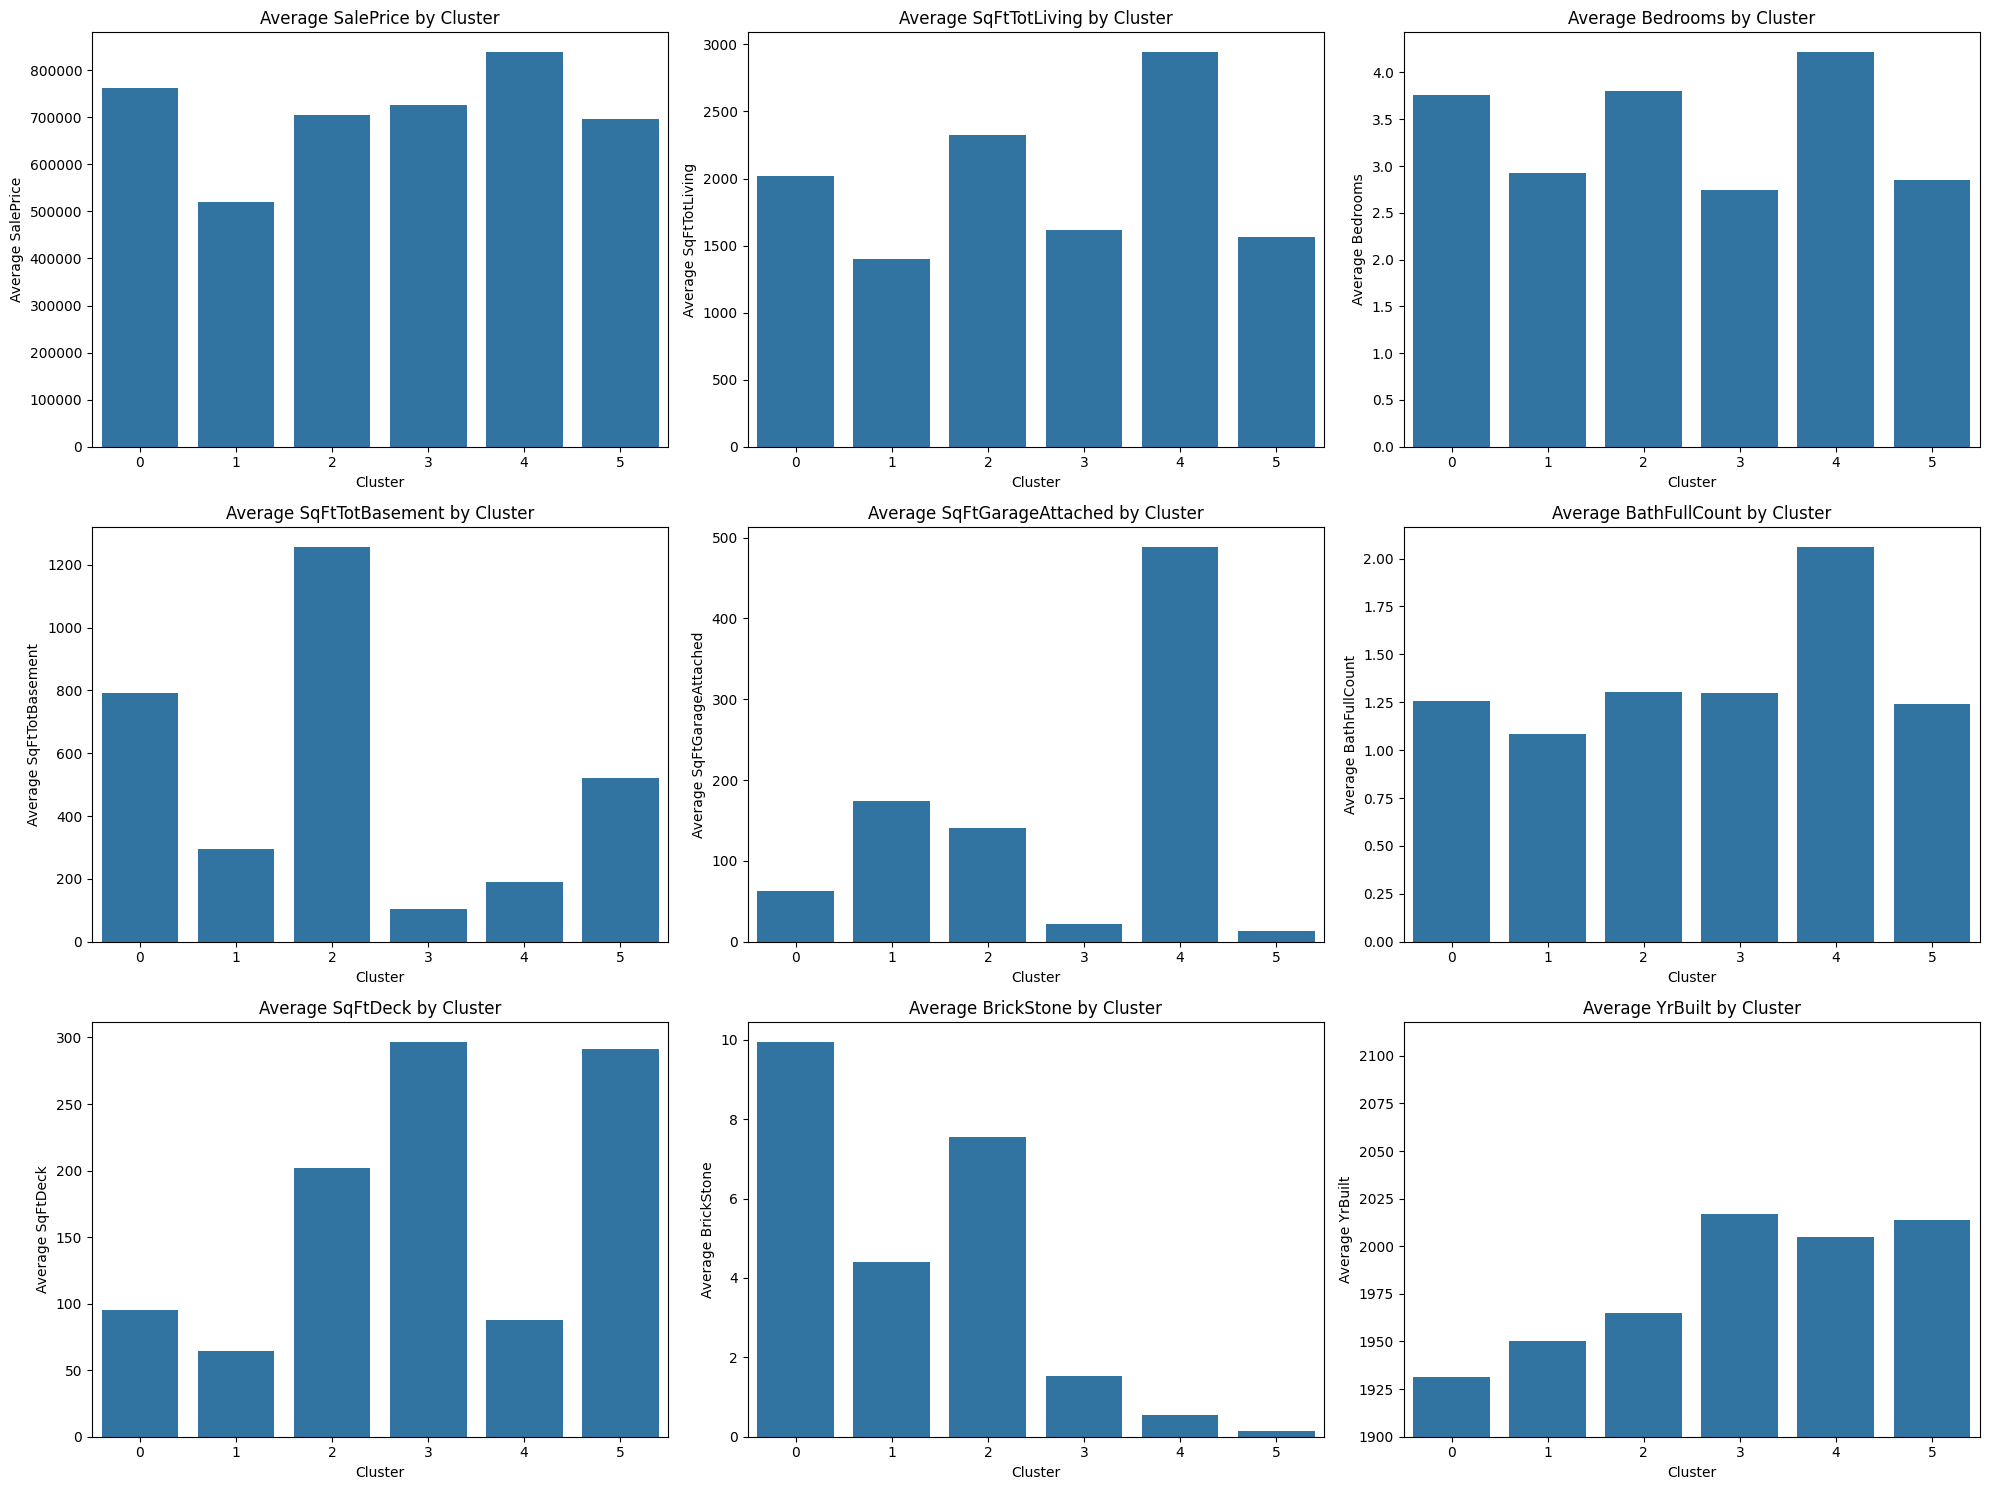

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20,15))
axes = axes.ravel()

features = [
    'SalePrice',
    'SqFtTotLiving',
    'Bedrooms',
    'SqFtTotBasement',
    'SqFtGarageAttached',
    'BathFullCount',
    'SqFtDeck',
    'BrickStone',
    'YrBuilt'
]

for i, col in enumerate(features):
    cluster_mean = df.groupby('Cluster')[col].mean().reset_index()
    sns.barplot(data=cluster_mean, x='Cluster', y=col, ax=axes[i])
    axes[i].set_title(f'Average {col} by Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(f'Average {col}')

    if col == 'YrBuilt':
        axes[i].set_ylim(1900, None) #make average year built starts from 1900

plt.tight_layout()
plt.show()

Cluster 0 – Traditional Family Homes
Older houses with solid brick/stone construction and large basements. These homes have moderate size and relatively high prices.
Suitable for: families who want strong, traditional houses with extra basement space.

Cluster 1 – Small Affordable Homes
These are the smallest and least expensive homes, with fewer bedrooms and smaller living areas.
Suitable for: first-time buyers, singles, or small households looking for affordable housing.

Cluster 2 – Large Family Homes with Big Basements
Large houses with many bedrooms and the largest basement areas in the dataset.
Suitable for: larger families who need extra space for storage, recreation, or additional living areas.

Cluster 3 – Modern Homes with Large Outdoor Decks
Medium-sized homes with large deck areas and smaller basements, usually built more recently.
Suitable for: buyers who value outdoor living spaces such as decks and patios.

Cluster 4 – Luxury Large Homes
The largest and most expensive houses, with many bedrooms, large garages, and newer construction.
Suitable for: high-income buyers looking for spacious luxury homes with many amenities.

Cluster 5 – Medium Modern Homes with Outdoor Space
Moderate-sized homes with medium prices and large deck areas. These homes balance indoor and outdoor living space.
Suitable for: families who want comfortable homes with outdoor areas for relaxation or entertainment.

#6 Modeling

## 6.1 Load a new dataset

In [ ]:

fpath2 = "/content/drive/My Drive/Colab Notebooks/Third Belt Exam/option_A_modeling_df - option_A_modeling_df.csv"
df2 = pd.read_csv(fpath2)
df2.head()

,SalePrice,SqFt1stFloor,SqFtHalfFloor,SqFt2ndFloor,SqFtUpperFloor,SqFtTotLiving,SqFtTotBasement,SqFtFinBasement,SqFtGarageBasement,SqFtGarageAttached,DaylightBasement,SqFtOpenPorch,SqFtEnclosedPorch,SqFtDeck,BrickStone,Bedrooms,BathHalfCount,Bath3qtrCount,BathFullCount,YrBuilt,PcntComplete,Longitude,Latitude,Golf Course,Other Great Outdoors,Elementary School,General Entertainment,Park,Mexican Restaurant,Vietnamese Restaurant,Gas Station,Housing Development,Playground,Pool,Church,Dive Bar,Convenience Store,Middle School,Grocery Store,Brewery,Bar,Salon / Barbershop,Post Office,Beach,Lake,Medical Center,Sandwich Place,Nail Salon,Pizza Place,Moving Target,Building,Preschool,Library,Trail,Farm,Community Center,High School,Gym / Fitness Center,Bridge,Gym,Supermarket,School,Dance Studio,Athletics & Sports,Garden,Airport,Beer Bar,Dog Run,Pharmacy,Scenic Lookout,Bank,Fast Food Restaurant,Miscellaneous Shop,Pet Store,Doctor's Office,Pub,Coffee Shop,Food Truck,Hardware Store,Bus Stop,Field,Laundry Service,Dentist's Office,Bus Station,Auto Dealership,Veterinarian,Tennis Court,Chinese Restaurant,Furniture / Home Store,Bus Line,Café,Event Space,Italian Restaurant,Marijuana Dispensary,Office,Yoga Studio,Restaurant,Baseball Field,Discount Store,Physical Therapist,American Restaurant,Martial Arts Dojo,Spa,Storage Facility,Daycare,General Travel,Burger Joint,Pet Service,Thai Restaurant,Chiropractor,Bakery,Mobile Phone Shop,Ice Cream Shop,Automotive Shop,Assisted Living,Health & Beauty Service,Fried Chicken Joint,Taco Place,Video Store,Financial or Legal Service,Massage Studio,Asian Restaurant,Insurance Office,Japanese Restaurant,ATM,Locksmith,Shipping Store,BldgGrade_4,BldgGrade_5,BldgGrade_6,BldgGrade_7,BldgGrade_8,BldgGrade_9,BldgGrade_10,BldgGrade_11,BldgGrade_12,FinBasementGrade_3,FinBasementGrade_4,FinBasementGrade_5,FinBasementGrade_6,FinBasementGrade_7,FinBasementGrade_8,FinBasementGrade_9,FinBasementGrade_10,HeatSystem_1,HeatSystem_2,HeatSystem_3,HeatSystem_4,HeatSystem_5,HeatSystem_6,HeatSystem_7,HeatSystem_8,Condition_2,Condition_3,Condition_4,Condition_5,MonthSold_02,MonthSold_03,MonthSold_04,MonthSold_05,MonthSold_06,MonthSold_07,MonthSold_08,MonthSold_09,MonthSold_10,MonthSold_11,MonthSold_12,YearSold_2017,YearSold_2018,YearSold_2019,YearSold_2020
0,400000,1590,0,0,0,3180,1590,1590,0,600,1,50,0,220,0,6,0,2,1,1965,0,-122.196399,47.336118,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
1,474250,1390,0,0,0,2200,810,810,0,0,1,0,0,340,0,4,1,0,1,1945,0,-122.361913,47.509874,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
2,667950,1010,0,1515,0,2525,0,0,0,400,0,167,0,0,0,4,1,0,2,2019,0,-122.156684,47.437557,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
3,659000,660,0,540,0,1820,620,620,0,0,1,0,0,100,0,3,1,0,2,2016,0,-122.370252,47.565146,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0
4,656500,2310,0,0,0,2310,0,0,0,440,0,40,0,320,0,3,0,0,2,1967,0,-122.184194,47.730389,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4937 entries, 0 to 4936
Columns: 171 entries, SalePrice to YearSold_2020
dtypes: float64(2), int64(169)
memory usage: 6.4 MB


## 6.2 Define X and y then Train-Test split

In [ ]:
X = df2.drop(columns=['SalePrice'])
y = df2['SalePrice']

X.shape, y.shape

((4937, 170), (4937,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

X_train.shape, X_test.shape

((3949, 170), (988, 170))

## 6.3 Scaling the Data

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape

((3949, 170), (988, 170))

## 6.4 Determining the Optimal Number of PCA Components

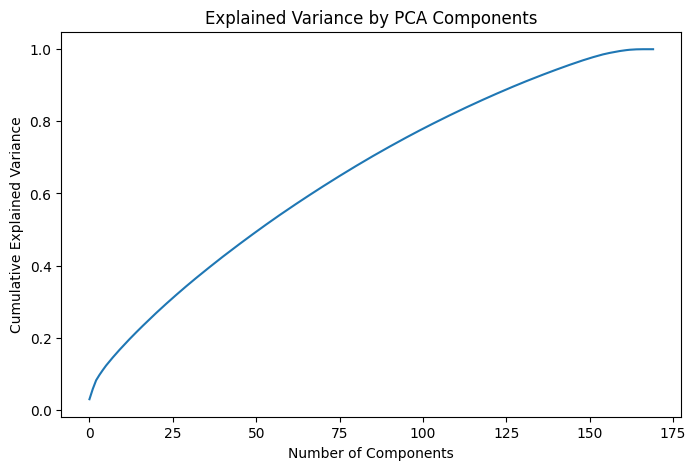

In [ ]:
pca = PCA()
pca.fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.show()

The PCA plot shows how much information is kept as we increase the number of components. about 120 components explain around 90% of the total variance. Therefore, we select 120 PCA components to keep most of the important information while reducing the number of features.

We now reduce the 170 features → 120 PCA components.

## 6.5 Apply PCA Transformation

In [ ]:
pca = PCA(n_components=120)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape, X_test_pca.shape

((3949, 120), (988, 120))

In [ ]:
input_shape = X_train_pca.shape[1]
input_shape

120

##6.6 Custom function for plotting history

In [ ]:
def plot_history(history, figsize=(6,12), marker='o'):

    metrics_list = [c for c in history.history if not c.startswith('val_')]

    fig, axes = plt.subplots(nrows=len(metrics_list), figsize=figsize)

    for i, metric_name in enumerate(metrics_list):
        ax = axes[i]
        metric_values = history.history[metric_name]
        epochs = history.epoch

        ax.plot(epochs, metric_values, label=metric_name, marker=marker)

        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            metric_values = history.history[val_metric_name]
            ax.plot(epochs, metric_values, label=val_metric_name, marker=marker)

        ax.legend()
        ax.set_title(metric_name)

    fig.tight_layout()
    return fig, axes

## 6.6 Deep Learning Model 1 (Baseline Model)

In [ ]:
model1 = Sequential()

model1.add(Dense(10,
                 input_dim=input_shape,
                 activation='relu'))
model1.add(Dense(10,
                 activation='relu'))
model1.add(Dense(1, activation='linear'))

model1.compile(loss='mse',
               optimizer='adam',
               metrics=[metrics.MeanAbsoluteError(),
                        metrics.RootMeanSquaredError()])

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │         1,210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331 (5.20 KB)

 Trainable params: 1,331 (5.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
history1 = model1.fit(X_train_pca, y_train,
                      validation_split=0.2,
                      epochs=100,
                      verbose=0,
                      callbacks=[early_stop])

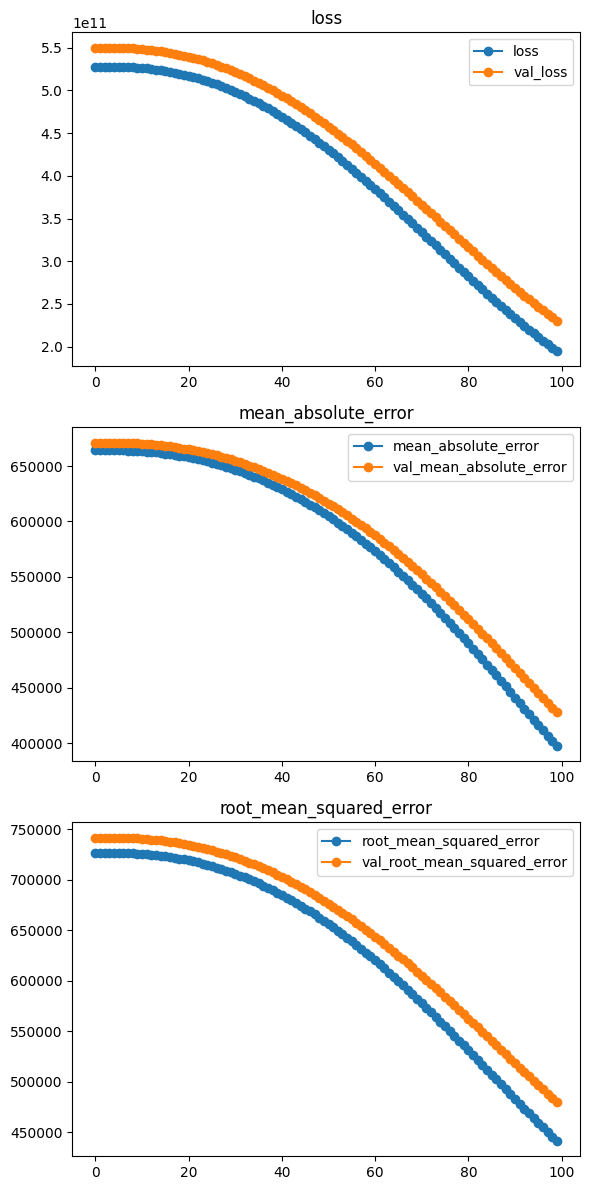

In [ ]:
plot_history(history1);

In [ ]:
y_pred1 = model1.predict(X_test_pca)

print(f'Model 1 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred1))}')
print(f'Model 1 MAE: {mean_absolute_error(y_test, y_pred1)}')
print(f'Model 1 R2: {r2_score(y_test, y_pred1)}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Model 1 RMSE: 452586.28002183186
Model 1 MAE: 405621.625
Model 1 R2: -1.3541231155395508


Model 1 was used as a baseline model. Although the loss decreased during training, the final evaluation metrics were weak, especially the negative R² score. This indicates that the model was too simple to capture the relationship between the PCA-transformed housing features and sale price (Underfitting). Therefore, a more complex model is needed.


## 6.7 Deep Learning Model 2

In [ ]:
model2 = Sequential()

model2.add(Dense(64,
                 input_dim=input_shape,
                 activation='relu'))
model2.add(Dense(32,
                 activation='relu'))
model2.add(Dropout(0.2))
model2.add(Dense(16,
                 activation='relu'))
model2.add(Dense(1, activation='linear'))

model2.compile(loss='mse',
               optimizer='adam',
               metrics=[metrics.MeanAbsoluteError(),
                        metrics.RootMeanSquaredError()])

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,369 (40.50 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop2 = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
history2 = model2.fit(X_train_pca, y_train,
                      validation_split=0.2,
                      epochs=100,
                      verbose=0,
                      callbacks=[early_stop2])

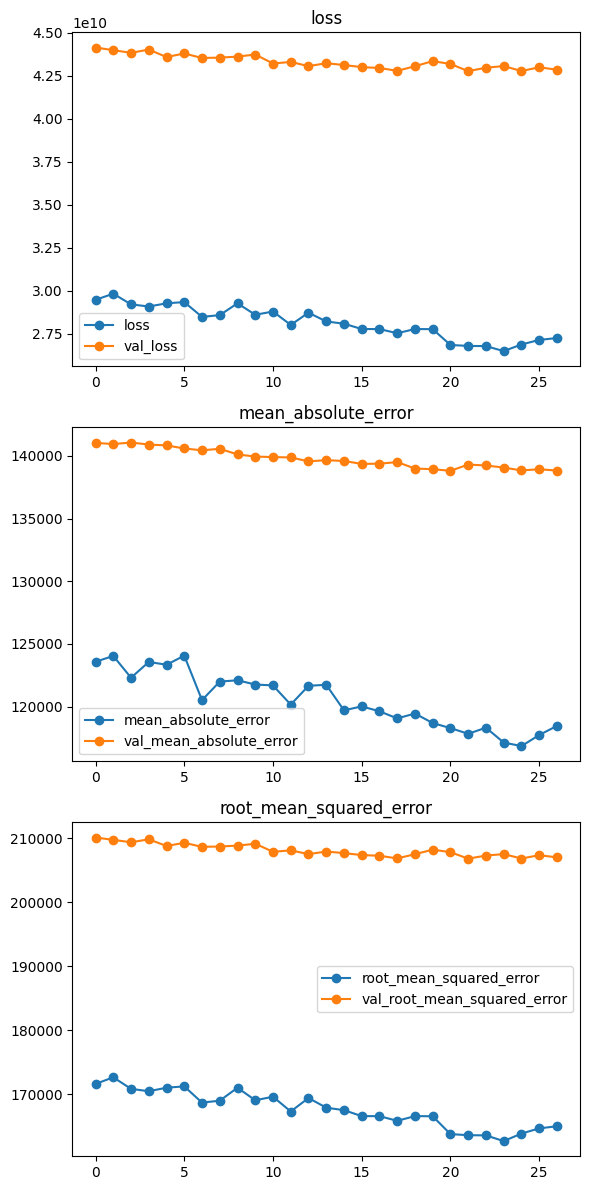

In [ ]:
plot_history(history2);

In [ ]:
y_pred2 = model2.predict(X_test_pca)

print(f'Model 2 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred2))}')
print(f'Model 2 MAE: {mean_absolute_error(y_test, y_pred2)}')
print(f'Model 2 R2: {r2_score(y_test, y_pred2)}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Model 2 RMSE: 198820.73581998434
Model 2 MAE: 138409.296875
Model 2 R2: 0.5456926822662354


Model 2 performs significantly better than Model 1.

The RMSE and MAE values decreased a lot, which means the prediction errors became much smaller. In addition, the R² score improved from a negative value to 0.55, meaning that Model 2 can explain about 55% of the variation in house prices, while Model 1 failed to learn meaningful patterns from the data.

This shows that Model 2 learned the relationships between the features and the sale price much better than Model 1.

- ***Increasing the Number of Nodes***:

  Model 1 used only 10 neurons per layer, which limited the model’s ability to learn complex relationships in the data.

  Model 2 increased the neurons to 64 → 32 → 16, allowing the network to capture more patterns and interactions between features. More neurons give the model greater capacity to learn from the data.


- ***Adding an Additional Hidden Layer***

   Model 1 had two hidden layers, while Model 2 introduced an additional hidden layerm thiss allows the neural network to learn deeper representations of the data, meaning the model can capture more complex nonlinear relationships between house features and sale prices.

- ***Adding Regularization (Dropout)***

   Model 2 also introduced a Dropout layer, which randomly disables some neurons during training, this helps prevent the model from memorizing the training data, forcing it to learn more general patterns that work better on new unseen data.

## 6.8 Deep Learning Model 3 (using Keras Tuner)

In [ ]:
def build_model(hp):

    model = Sequential()

    model.add(Dense(
        units=hp.Int('units_layer1', min_value=32, max_value=128, step=16),
        activation='relu',
        input_dim=input_shape
    ))

    model.add(Dense(
        units=hp.Int('units_layer2', min_value=16, max_value=64, step=16),
        activation='relu'
    ))

    model.add(Dropout(
        hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    ))

    model.add(Dense(1, activation='linear'))

    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'rmsprop', 'nadam']),
        loss='mse',
        metrics=[metrics.MeanAbsoluteError(),
                 metrics.RootMeanSquaredError()]
    )

    return model

In [ ]:
#create tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    overwrite=True,
    seed=42,
    project_name='house_price_tuning'
)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
#try many models
tuner.search(
    X_train_pca,
    y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Trial 90 Complete [00h 00m 27s]
val_loss: 83246546944.0

Best val_loss So Far: 52254539776.0
Total elapsed time: 00h 13m 11s


In [ ]:
#best hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]
best_hps.values

{'units_layer1': 128,
 'units_layer2': 64,
 'dropout_rate': 0.30000000000000004,
 'optimizer': 'adam',
 'tuner/epochs': 50,
 'tuner/initial_epoch': 17,
 'tuner/bracket': 3,
 'tuner/round': 3,
 'tuner/trial_id': '0047'}

In [ ]:
#best model
best_model = tuner.get_best_models()[0]
best_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,809 (93.00 KB)

 Trainable params: 23,809 (93.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#evaluate the best model
y_pred3 = best_model.predict(X_test_pca)

print(f'Final Model RMSE: {np.sqrt(mean_squared_error(y_test, y_pred3))}')
print(f'Final Model MAE: {mean_absolute_error(y_test, y_pred3)}')
print(f'Final Model R2: {r2_score(y_test, y_pred3)}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Final Model RMSE: 225439.23463319335
Final Model MAE: 163974.875
Final Model R2: 0.41590243577957153


Although Keras Tuner selected the best model based on validation loss, the final tuned model performed slightly worse than Model 2 on the test set. This suggests that the tuned model did not generalize as well as expected.

## 6.9 Final Improved Deep Learning Model

In [ ]:
model4 = Sequential()

model4.add(Dense(128,
                 input_dim=input_shape,
                 activation='relu'))
model4.add(Dense(64,
                 activation='relu'))
model4.add(Dropout(0.3))
model4.add(Dense(32,
                 activation='relu'))
model4.add(Dense(1, activation='linear'))

model4.compile(loss='mse',
               optimizer='adam',
               metrics=[metrics.MeanAbsoluteError(),
                        metrics.RootMeanSquaredError()])

model4.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop4 = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
history4 = model4.fit(X_train_pca, y_train,
                      validation_split=0.2,
                      epochs=100,
                      verbose=0,
                      callbacks=[early_stop4])

In [ ]:
y_pred4 = model4.predict(X_test_pca)

print(f'Model 4 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred4))}')
print(f'Model 4 MAE: {mean_absolute_error(y_test, y_pred4)}')
print(f'Model 4 R2: {r2_score(y_test, y_pred4)}')

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Model 4 RMSE: 197182.2343315949
Model 4 MAE: 137467.1875
Model 4 R2: 0.5531498193740845


Based on the evaluation metrics, the final model shows a reasonable ability to predict house sale prices. The model achieved an R² score of about 0.55, which means it can explain around 55% of the variation in house prices using the available features. The MAE of about 137,000 indicates that, on average, the model's predictions are off by around $137,000, while the RMSE of about 197,000 shows that larger errors can still occur.

Overall, the model can provide useful price estimates and general trends, which can help stakeholders understand how different house features influence price. However, the error values show that the model is not perfectly accurate, so its predictions should be used as guidance rather than exact price estimates.